In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import optuna

C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import gaussian_kde
C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Plotting Loss Curves for Pick-Ups

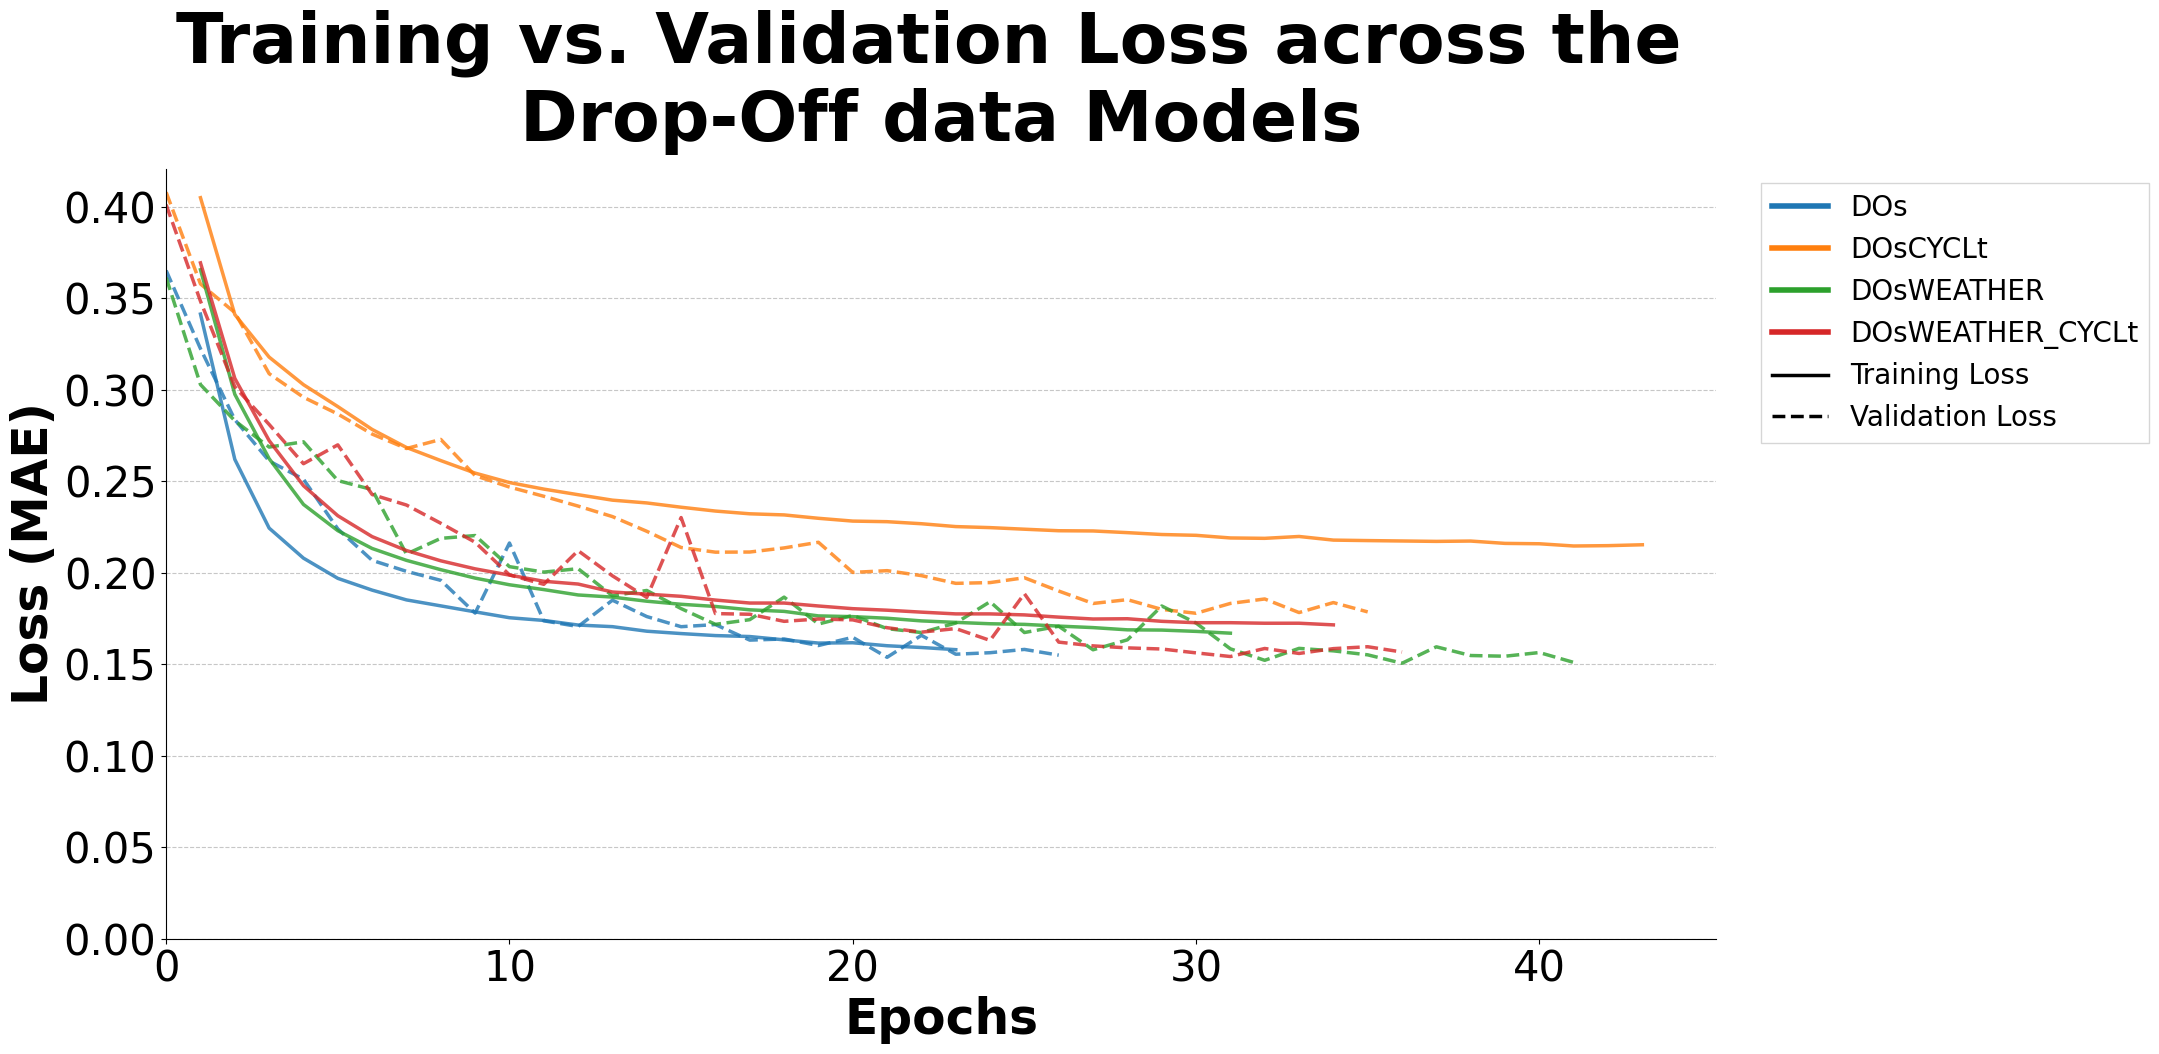

In [ ]:
import os
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import kagglehub

# ---------------------------------------------------------
# 1. Configuration & Plot Setup
# ---------------------------------------------------------
# Define the working directory and the SQLite database containing Optuna trials
base_path = kagglehub.dataset_download("florianhinrichsen/neuralnetwork")
storage_url = f"sqlite:///{base_path}/FFNN_tuning.db"

# Define the Drop-Off datasets to evaluate
model_names = ["DOs", "DOsCYCLt", "DOsWEATHER", "DOsWEATHER_CYCLt"]

plt.figure(figsize=(20, 10))

# Generate a distinct color palette for the 4 datasets
colors = sns.color_palette("tab10", 4)

# ---------------------------------------------------------
# 2. Data Extraction & Curve Plotting Loop (AI generated)
# ---------------------------------------------------------
for i, name in enumerate(model_names):
    # Construct expected file and Optuna study names for the current dataset
    csv_filename = f"df_{name}_history.csv"
    study_name = f"NN_df_{name}"
    csv_file = os.path.join(base_path, csv_filename)

    # --- Extract Validation Loss from Optuna ---
    # Load the study from the database and retrieve the best performing trial
    study = optuna.load_study(study_name=study_name, storage=storage_url)
    best_trial = study.best_trial

    # Extract intermediate validation losses (recorded per epoch during pruning)
    val_dict = best_trial.intermediate_values
    val_epochs = sorted(val_dict.keys())
    val_loss = [val_dict[epoch] for epoch in val_epochs]

    # --- Extract Training Loss from CSV ---
    # Load the standard Keras/TensorFlow training history
    train_df = pd.read_csv(csv_file)
    train_loss = train_df["loss"]
    train_epochs = np.arange(1, len(train_loss) + 1)

    # --- Plot the curves ---
    # Plot Training Loss as a solid line
    plt.plot(train_epochs, train_loss, color=colors[i], linestyle='-', linewidth=2.5, alpha=0.8)
    # Plot Validation Loss as a dashed line
    plt.plot(val_epochs, val_loss, color=colors[i], linestyle='--', linewidth=2.5, alpha=0.8)

# ---------------------------------------------------------
# 3. Custom Legend Construction (AI generated)
# ---------------------------------------------------------
# Create proxy artists (Line2D objects) to build a combined legend for colors and linestyles
# 1. Match dataset names to their respective colors
custom_lines = [Line2D([0], [0], color=colors[i], lw=4) for i in range(4)]
# 2. Match line styles to loss types (Train = solid, Val = dashed)
style_lines = [
    Line2D([0], [0], color='black', lw=2.5, linestyle='-'),
    Line2D([0], [0], color='black', lw=2.5, linestyle='--')
]

# Combine the handles and labels into a single unified legend
legend_handles = custom_lines + style_lines
legend_labels = model_names + ["Training Loss", "Validation Loss"]

plt.legend(
    legend_handles, 
    legend_labels, 
    fontsize=20, 
    loc="upper left", 
    bbox_to_anchor=(1.02, 1), 
    fancybox=False
)

# ---------------------------------------------------------
# 4. Text Formatting, Layout & Export
# ---------------------------------------------------------
plt.title("Training vs. Validation Loss across the \nDrop-Off data Models", fontsize=50, fontweight="bold", pad=20)
plt.xlabel("Epochs", fontweight="bold", fontsize=35)
plt.ylabel("Loss (MAE)", fontweight="bold", fontsize=35)

# Format ticks and constrain axes to start at zero
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlim(left=0) 
plt.ylim(bottom=0)

# Add a dashed horizontal grid and ensure it renders behind the plot lines
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.gca().set_axisbelow(True)

# Remove the top and right spines for a cleaner aesthetic
sns.despine()

# plt.savefig(os.path.join(base_path, "LossCurvesDOs.pdf"), dpi=300, bbox_inches="tight")
plt.show()



Plotting Loss Curves for Drop-Offs

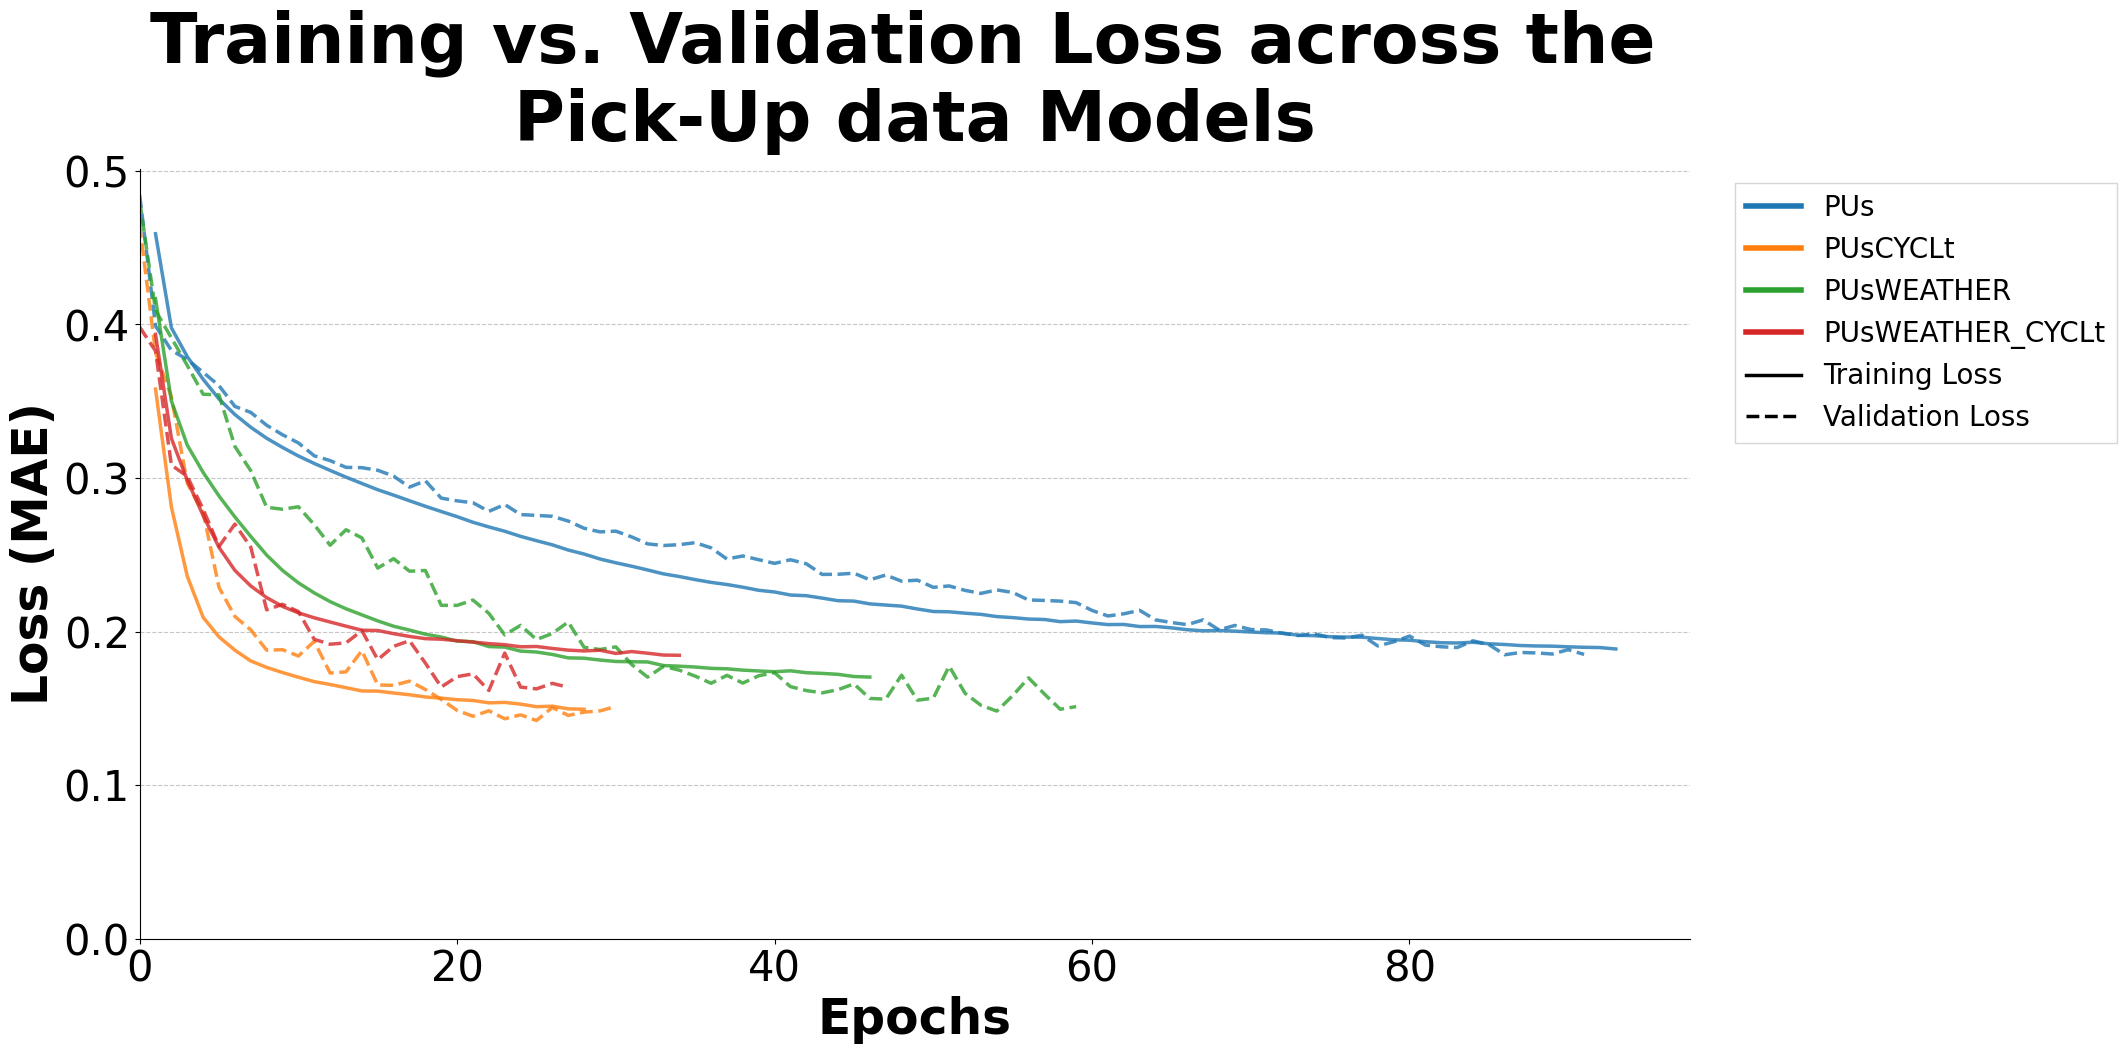

In [ ]:
import os
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# 1. Configuration & Plot Setup
# ---------------------------------------------------------
# Define the working directory and the SQLite database containing Optuna trials
base_path = kagglehub.dataset_download("florianhinrichsen/neuralnetwork")
storage_url = f"sqlite:///{base_path}/FFNN_tuning.db"

# Define the Pick-Up (PU) datasets to evaluate
model_names = ["PUs", "PUsCYCLt", "PUsWEATHER", "PUsWEATHER_CYCLt"]

plt.figure(figsize=(20, 10))

# Generate a distinct color palette for the 4 datasets
colors = sns.color_palette("tab10", 4)

# ---------------------------------------------------------
# 2. Data Extraction & Curve Plotting Loop (AI generated)
# ---------------------------------------------------------
for i, name in enumerate(model_names):
    # Construct expected file and Optuna study names for the current dataset
    csv_filename = f"df_{name}_history.csv"
    study_name = f"NN_df_{name}"
    csv_file = os.path.join(base_path, csv_filename)

    # --- Extract Validation Loss from Optuna ---
    # Load the study from the database and retrieve the best performing trial
    study = optuna.load_study(study_name=study_name, storage=storage_url)
    best_trial = study.best_trial

    # Extract intermediate validation losses (recorded per epoch during pruning)
    val_dict = best_trial.intermediate_values
    val_epochs = sorted(val_dict.keys())
    val_loss = [val_dict[epoch] for epoch in val_epochs]

    # --- Extract Training Loss from CSV ---
    # Load the standard Keras/TensorFlow training history
    train_df = pd.read_csv(csv_file)
    train_loss = train_df["loss"]
    train_epochs = np.arange(1, len(train_loss) + 1)

    # --- Plot the curves ---
    # Plot Training Loss as a solid line
    plt.plot(train_epochs, train_loss, color=colors[i], linestyle='-', linewidth=2.5, alpha=0.8)
    # Plot Validation Loss as a dashed line
    plt.plot(val_epochs, val_loss, color=colors[i], linestyle='--', linewidth=2.5, alpha=0.8)

# ---------------------------------------------------------
# 3. Custom Legend Construction (AI generated)
# ---------------------------------------------------------
# Create proxy artists (Line2D objects) to build a combined legend for colors and linestyles
# 1. Match dataset names to their respective colors
custom_lines = [Line2D([0], [0], color=colors[i], lw=4) for i in range(4)]
# 2. Match line styles to loss types (Train = solid, Val = dashed)
style_lines = [
    Line2D([0], [0], color='black', lw=2.5, linestyle='-'),
    Line2D([0], [0], color='black', lw=2.5, linestyle='--')
]

# Combine the handles and labels into a single unified legend
legend_handles = custom_lines + style_lines
legend_labels = model_names + ["Training Loss", "Validation Loss"]

plt.legend(
    legend_handles, 
    legend_labels, 
    fontsize=20, 
    loc="upper left", 
    bbox_to_anchor=(1.02, 1), 
    fancybox=False
)

# ---------------------------------------------------------
# 4. Text Formatting, Layout & Export
# ---------------------------------------------------------
plt.title("Training vs. Validation Loss across the \nPick-Up data Models", fontsize=50, fontweight="bold", pad=20)
plt.xlabel("Epochs", fontweight="bold", fontsize=35)
plt.ylabel("Loss (MAE)", fontweight="bold", fontsize=35)

# Format ticks and constrain axes to start at zero
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlim(left=0) 
plt.ylim(bottom=0)

# Add a dashed horizontal grid and ensure it renders behind the plot lines
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.gca().set_axisbelow(True)

# Remove the top and right spines for a cleaner aesthetic
sns.despine()

# plt.savefig(os.path.join(base_path, "LossCurvesPUs.pdf"), dpi=300, bbox_inches="tight")
plt.show()

